In [11]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess          # ← this was missing
import tempfile
import os

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization import ZScaleInterval, ImageNormalize

from photutils.detection import DAOStarFinder
from photutils.background import Background2D, MedianBackground

print("✅ All imports successful")

✅ All imports successful


In [39]:
IMAGE_PATH       = "your_image.fits"   # FITS, JPG, or PNG

FOCAL_LENGTH_MM  = 500.0               # your telescope focal length in mm
PIXEL_SIZE_UM    = 3.76                # your camera pixel size in micrometers

ASTAP_EXE        = r"C:\Program Files\astap\astap.exe"
ASTAP_DATA_DIR   = r"C:\Program Files\astap"                # e.g. r"C:\Program Files\astap"  or None for default

APPROX_RA_DEG    =    166.3480151835              # optional pointing hint, e.g. 83.82
APPROX_DEC_DEG   =    11.5965037982        # e.g. -5.39
SEARCH_RADIUS_DEG = 180

DETECTION_SIGMA  = 4
MAX_STARS        = 100
MIN_STARS         = 10

# --- derived ---
PIXEL_SCALE_ARCSEC = 206.265 * PIXEL_SIZE_UM / FOCAL_LENGTH_MM

print(f"📐 Pixel scale : {PIXEL_SCALE_ARCSEC:.4f} arcsec/pixel")
print(f"   Focal length : {FOCAL_LENGTH_MM} mm")
print(f"   Pixel size   : {PIXEL_SIZE_UM} µm")

if not Path(ASTAP_EXE).exists():
    print(f"\n⚠️  ASTAP not found at: {ASTAP_EXE}")
    print("   Download from: https://www.hnsky.org/astap.htm")
else:
    print(f"\n✅ ASTAP found: {ASTAP_EXE}")

📐 Pixel scale : 1.5511 arcsec/pixel
   Focal length : 500.0 mm
   Pixel size   : 3.76 µm

✅ ASTAP found: C:\Program Files\astap\astap.exe


✅ Image loaded: 3010 × 3010 pixels
   Estimated FOV: 77.8' × 77.8' (1.30° × 1.30°)
   Pixel range: 18292 – 65534


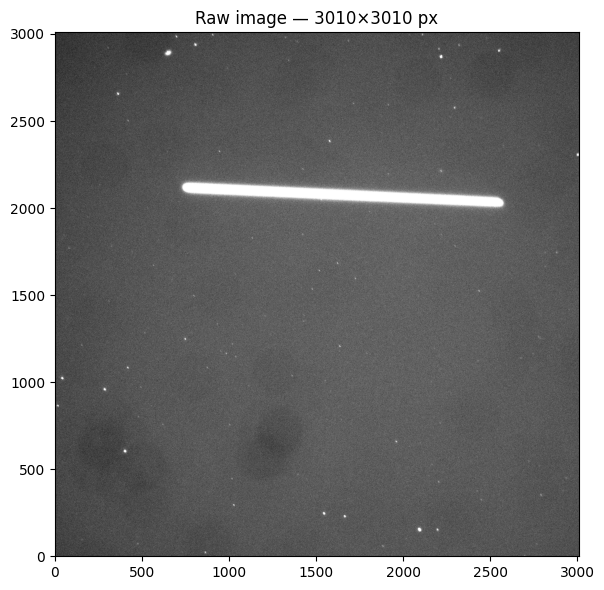

In [40]:
def load_image(path):
    """
    Load an astronomical image from FITS, JPG, or PNG.
    Returns: (image_data_2d, header_or_None)
    """
    path = Path(r"D:\Pratyay\Observations sorted\Pass 48274\48274_00032.fits")
    suffix = path.suffix.lower()

    if suffix in (".fits", ".fit", ".fts"):
        hdul = fits.open(path)
        # Use first image HDU with data
        for hdu in hdul:
            if hdu.data is not None and hdu.data.ndim >= 2:
                data = hdu.data.astype(np.float64)
                header = hdu.header
                break
        hdul.close()
        # Handle 3D FITS (e.g., RGB color or stacked cubes) → take first plane
        if data.ndim == 3:
            data = data[0]
        return data, header

    elif suffix in (".jpg", ".jpeg", ".png", ".tiff", ".tif"):
        from PIL import Image
        img = Image.open(path).convert("L")  # convert to grayscale
        data = np.array(img, dtype=np.float64)
        return data, None

    else:
        raise ValueError(f"Unsupported image format: {suffix}")


image_data, fits_header = load_image(IMAGE_PATH)
img_h, img_w = image_data.shape

# Estimate FOV
fov_w_arcmin = PIXEL_SCALE_ARCSEC * img_w / 60
fov_h_arcmin = PIXEL_SCALE_ARCSEC * img_h / 60

print(f"✅ Image loaded: {img_w} × {img_h} pixels")
print(f"   Estimated FOV: {fov_w_arcmin:.1f}' × {fov_h_arcmin:.1f}' "
      f"({fov_w_arcmin/60:.2f}° × {fov_h_arcmin/60:.2f}°)")
print(f"   Pixel range: {image_data.min():.0f} – {image_data.max():.0f}")

# Quick preview
norm = ImageNormalize(image_data, interval=ZScaleInterval())
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(image_data, cmap="gray", norm=norm, origin="lower")
ax.set_title(f"Raw image — {img_w}×{img_h} px")
plt.tight_layout()
plt.show()

⭐ Detected 46 stars


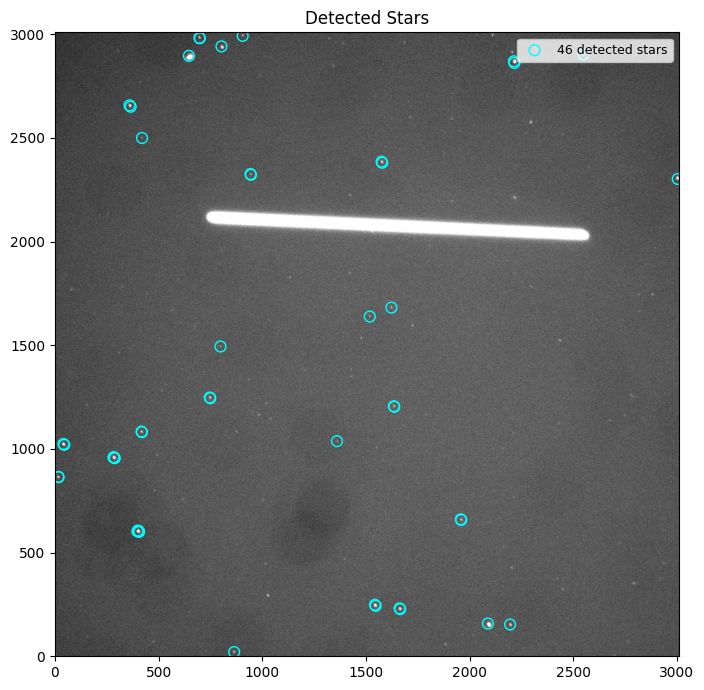


Top 10 stars (x, y, peak flux):
        x                  y                 peak               flux       
------------------ ------------------ ------------------ ------------------
 697.3917548125481  2983.069571511745  34250.99456746177  555926.5950904029
 646.1946996260833   2896.08468289136  34162.39986155962  724388.4181660574
359.56870826394464 2657.5344724315596  33943.26496053976  615060.5211655009
 365.4017728767608 2650.7140116088417  33910.70966530953  458600.4101759212
 803.2771159334801 2941.6584959877755    33794.657981977   455399.465243997
 397.8823199165381  602.3017298574051  33729.89133361696  720231.9011814565
400.46094646552865  606.1466229948475 33672.150498114686  709820.2657727154
 404.9859388732928  599.7876879260994 33645.268154856705  632029.4593678549
 406.1931621920601  601.0231461680238  33618.08662874678  691959.9387257402
 16.22440163006731  865.2257505475604 33554.242381980934 468545.10406858247


In [41]:
def detect_stars(image, sigma_threshold=3.0, max_stars=150, fwhm_guess=3.0):
    """
    Detect stars in image using DAOStarFinder.

    Parameters
    ----------
    image          : 2D numpy array
    sigma_threshold: how many σ above background a source must be
    max_stars      : keep only the brightest N stars
    fwhm_guess     : estimated star FWHM in pixels (2–5 typical for well-focused stars)

    Returns
    -------
    sources : astropy Table with columns x, y, peak, flux, ...
    """
    # ── 1. Estimate and subtract background ──────────────────
    bkg_estimator = MedianBackground()
    bkg = Background2D(image, box_size=64, filter_size=3,
                       bkg_estimator=bkg_estimator)
    image_sub = image - bkg.background

    # ── 2. Run DAOStarFinder ─────────────────────────────────
    std = np.std(image_sub)
    daofind = DAOStarFinder(fwhm=fwhm_guess,
                            threshold=sigma_threshold * std)
    sources = daofind(image_sub)

    if sources is None or len(sources) == 0:
        raise RuntimeError(
            "No stars detected! Try lowering DETECTION_SIGMA or checking focus."
        )

    # ── 3. Sort by flux (brightness), keep top N ─────────────
    sources.sort("peak")
    sources.reverse()
    sources = sources[:max_stars]

    # Rename to x, y for clarity
    sources["x"] = sources["xcentroid"]
    sources["y"] = sources["ycentroid"]

    return sources, image_sub


sources, image_sub = detect_stars(
    image_data,
    sigma_threshold=DETECTION_SIGMA,
    max_stars=MAX_STARS,
    fwhm_guess      = 4.5
)

n = len(sources)
print(f"⭐ Detected {n} stars")
if n < MIN_STARS:
    print(f"⚠️  Warning: fewer than {MIN_STARS} stars. "
          "Try lowering DETECTION_SIGMA or adjusting fwhm_guess.")

# Show detection overlay
norm = ImageNormalize(image_data, interval=ZScaleInterval())
fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(image_data, cmap="gray", norm=norm, origin="lower")
ax.scatter(sources["x"], sources["y"],
           s=60, facecolors="none", edgecolors="cyan", linewidths=1.0,
           label=f"{n} detected stars")
ax.set_title("Detected Stars")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 stars (x, y, peak flux):")
print(sources[["x", "y", "peak", "flux"]][:10])

In [42]:
import subprocess
import os
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np


def save_temp_fits(image_data, path):
    """Save image preserving original bit depth — ASTAP works best with uint16."""
    data = image_data.astype(np.float32)
    hdu  = fits.PrimaryHDU(data=data)
    # Tell ASTAP this is a 16-bit-range image
    hdu.header["BITPIX"] = -32
    hdu.header["BZERO"]  = 0
    hdu.header["BSCALE"] = 1
    fits.HDUList([hdu]).writeto(path, overwrite=True)


def plate_solve_astap(image_data, pixel_scale_arcsec, image_width, image_height,
                      astap_exe, astap_data_dir=None, db_name="d50",
                      approx_ra=None, approx_dec=None, search_radius_deg=30.0):

    astap_exe = Path(astap_exe)
    if not astap_exe.exists():
        raise FileNotFoundError(f"ASTAP not found at: {astap_exe}")

    work_dir = Path("astap_workdir")
    work_dir.mkdir(exist_ok=True)
    tmp_fits = work_dir / "input.fits"
    wcs_file = work_dir / "input.wcs"
    ini_file = work_dir / "input.ini"

    for f in [wcs_file, ini_file]:
        if f.exists():
            f.unlink()

    save_temp_fits(image_data, tmp_fits)
    print(f"📄 FITS written: {tmp_fits.resolve()}")

    fov_deg = pixel_scale_arcsec * max(image_width, image_height) / 3600.0
    print(f"   FOV : {fov_deg:.4f}°  ({fov_deg*60:.2f} arcmin)")
    print(f"   DB  : {db_name}")

    if search_radius_deg > 90:
        search_radius_deg = 60.0

    cmd = [str(astap_exe)]
    cmd += ["-f",   str(tmp_fits.resolve())]
    cmd += ["-fov", f"{fov_deg:.4f}"]
    cmd += ["-r",   f"{search_radius_deg:.1f}"]
    cmd += ["-o",   str((work_dir / "input").resolve())]
    cmd += ["-s",   db_name]
    cmd += ["-exit"]
    cmd += ["-m",   "6"]       # accept as few as 6 matched stars
    cmd += ["-t",   "2"]       # low internal detection threshold

    if astap_data_dir is not None:
        cmd += ["-d", str(Path(astap_data_dir).resolve())]

    if approx_ra is not None and approx_dec is not None:
        if not (0 <= approx_ra <= 360):
            raise ValueError(f"RA must be 0–360, got {approx_ra}")
        if not (-90 <= approx_dec <= 90):
            raise ValueError(f"Dec must be -90–+90, got {approx_dec}")
        spd = 90.0 + approx_dec
        cmd += ["-ra",  f"{approx_ra:.6f}"]
        cmd += ["-spd", f"{spd:.6f}"]
        print(f"   Hint: RA={approx_ra:.4f}°  Dec={approx_dec:.4f}°")
    else:
        print("   Blind solve")

    print(f"\n🔍 Running ASTAP…")
    print("   " + " ".join(f'"{c}"' if " " in c else c for c in cmd))

    proc = subprocess.run(
        cmd, capture_output=True, text=True, timeout=120,
        creationflags=subprocess.CREATE_NO_WINDOW
    )

    print(f"\n   Return code : {proc.returncode}")
    print(f"   stdout      : {proc.stdout.strip() or '(none)'}")
    print(f"   stderr      : {proc.stderr.strip() or '(none)'}")
    print("\n   Files produced:")
    for f in sorted(work_dir.iterdir()):
        print(f"     {f.name}  ({f.stat().st_size} bytes)")

    if not wcs_file.exists():
        if ini_file.exists():
            print("\n--- input.ini ---")
            print(ini_file.read_text())
        raise RuntimeError("❌ Solve failed — no .wcs produced.")

    with fits.open(wcs_file) as hdul:
        wcs    = WCS(hdul[0].header)
        header = hdul[0].header
        cd11   = header.get("CD1_1", None)
        result = {
            "center_ra_deg":          header.get("CRVAL1"),
            "center_dec_deg":         header.get("CRVAL2"),
            "scale_arcsec_per_pixel": abs(cd11)*3600 if cd11 else pixel_scale_arcsec,
        }

    return wcs, result


wcs_solution, solve_result = plate_solve_astap(
    image_data,
    pixel_scale_arcsec = PIXEL_SCALE_ARCSEC,
    image_width        = img_w,
    image_height       = img_h,
    astap_exe          = ASTAP_EXE,
    astap_data_dir     = ASTAP_DATA_DIR,
    db_name            = "d50",
    approx_ra          = APPROX_RA_DEG,
    approx_dec         = APPROX_DEC_DEG,
    search_radius_deg  = SEARCH_RADIUS_DEG,
)

ra_deg  = solve_result["center_ra_deg"]
dec_deg = solve_result["center_dec_deg"]
c       = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg)
print("\n✅ PLATE SOLVE SUCCEEDED")
print(f"   Center RA  : {ra_deg:.6f}°  "
      f"({c.ra.to_string(unit=u.hourangle, sep='hms', precision=2)})")
print(f"   Center Dec : {dec_deg:.6f}°  "
      f"({c.dec.to_string(sep='dms', precision=1, alwayssign=True)})")
print(f"   Scale      : {solve_result['scale_arcsec_per_pixel']:.4f} arcsec/pixel")

📄 FITS written: C:\Users\astro\Desktop\Codes\astap_workdir\input.fits
   FOV : 1.2969°  (77.81 arcmin)
   DB  : d50
   Hint: RA=166.3480°  Dec=11.5965°

🔍 Running ASTAP…
   "C:\Program Files\astap\astap.exe" -f C:\Users\astro\Desktop\Codes\astap_workdir\input.fits -fov 1.2969 -r 60.0 -o C:\Users\astro\Desktop\Codes\astap_workdir\input -s d50 -exit -m 6 -t 2 -d "C:\Program Files\astap" -ra 166.348015 -spd 101.596504

   Return code : 1
   stdout      : (none)
   stderr      : (none)

   Files produced:
     input.fits  (36244800 bytes)
     input.ini  (291 bytes)

--- input.ini ---
PLTSOLVD=F
CMDLINE="C:\Program Files\astap\astap.exe" -f C:\Users\astro\Desktop\Codes\astap_workdir\input.fits -fov 1.2969 -r 60.0 -o C:\Users\astro\Desktop\Codes\astap_workdir\input -s d50 -exit -m 6 -t 2 -d "C:\Program Files\astap" -ra 166.348015 -spd 101.596504
DIMENSIONS=3010 x 3010



RuntimeError: ❌ Solve failed — no .wcs produced.

=== IMAGE STATISTICS ===
  Shape  : (3010, 3010)
  Min    : 18292.00
  Max    : 65534.00
  Mean   : 33567.22
  Median : 33202.00
  Std    : 4468.99

  Background-subtracted std: 3945.58

=== STAR COUNT AT DIFFERENT THRESHOLDS ===
  sigma=5.0 →    6 stars  ⚠️ 
  sigma=3.0 →  190 stars  ✅
  sigma=2.5 → 2103 stars  ✅
  sigma=2.0 → 17066 stars  ✅
  sigma=1.5 → 80196 stars  ✅

=== VISUAL CHECK ===


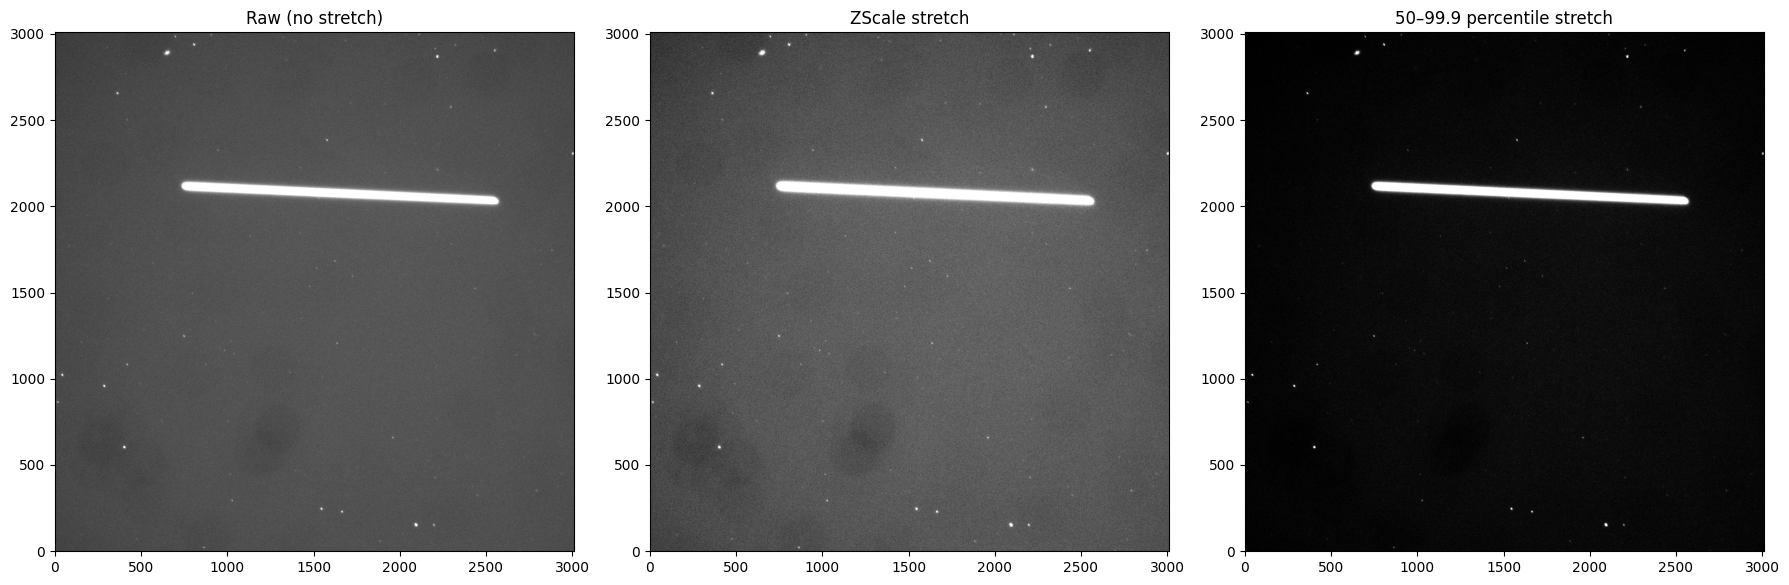

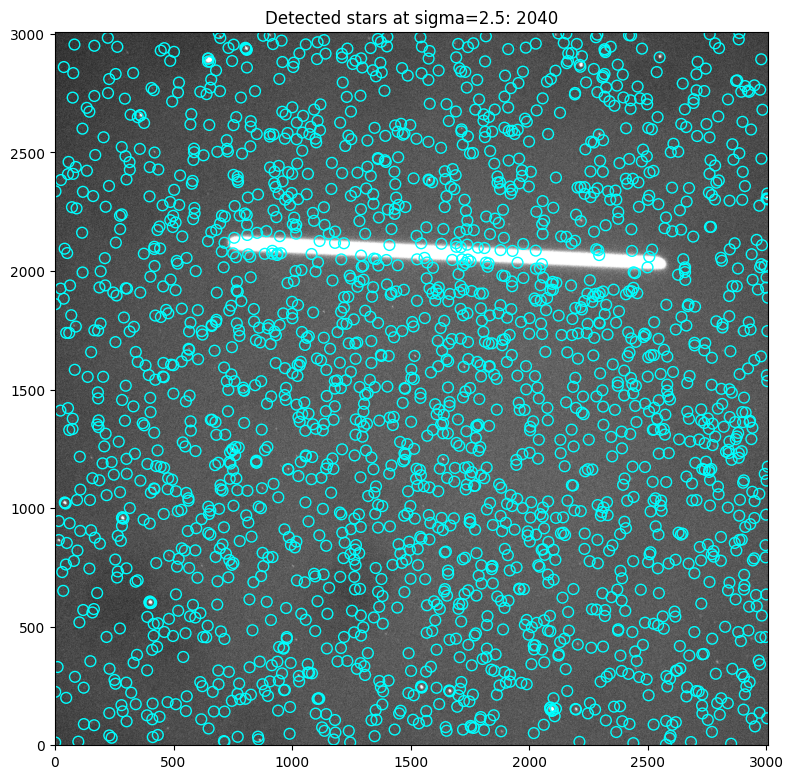

In [ ]:
# ── Run this before anything else ────────────────────────────

from photutils.detection import DAOStarFinder
from photutils.background import Background2D, MedianBackground
from astropy.visualization import ZScaleInterval, ImageNormalize
import matplotlib.pyplot as plt
import numpy as np

print("=== IMAGE STATISTICS ===")
print(f"  Shape  : {image_data.shape}")
print(f"  Min    : {image_data.min():.2f}")
print(f"  Max    : {image_data.max():.2f}")
print(f"  Mean   : {image_data.mean():.2f}")
print(f"  Median : {np.median(image_data):.2f}")
print(f"  Std    : {image_data.std():.2f}")

bkg       = Background2D(image_data, box_size=64, filter_size=3,
                          bkg_estimator=MedianBackground())
image_sub = image_data - bkg.background
std       = np.std(image_sub)
print(f"\n  Background-subtracted std: {std:.2f}")

print("\n=== STAR COUNT AT DIFFERENT THRESHOLDS ===")
for sigma in [5.0, 3.0, 2.5, 2.0, 1.5]:
    finder  = DAOStarFinder(fwhm=3.0, threshold=sigma * std)
    sources = finder(image_sub)
    n = len(sources) if sources else 0
    flag = "✅" if n >= 15 else "⚠️ "
    print(f"  sigma={sigma:.1f} → {n:4d} stars  {flag}")

print("\n=== VISUAL CHECK ===")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Raw image
axes[0].imshow(image_data, cmap="gray", origin="lower")
axes[0].set_title("Raw (no stretch)")

# ZScale
norm = ImageNormalize(image_data, interval=ZScaleInterval())
axes[1].imshow(image_data, cmap="gray", norm=norm, origin="lower")
axes[1].set_title("ZScale stretch")

# Hard percentile stretch
lo = np.percentile(image_data, 50)
hi = np.percentile(image_data, 99.9)
axes[2].imshow(image_data, cmap="gray", vmin=lo, vmax=hi, origin="lower")
axes[2].set_title("50–99.9 percentile stretch")

plt.tight_layout()
plt.show()

# Stars overlaid at sigma=2.5
finder2  = DAOStarFinder(fwhm=4.0, threshold=2.5 * std)
sources2 = finder2(image_sub)
n2 = len(sources2) if sources2 else 0
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_data, cmap="gray", norm=norm, origin="lower")
if sources2:
    ax.scatter(sources2["xcentroid"], sources2["ycentroid"],
               s=60, facecolors="none", edgecolors="cyan", linewidths=1.0)
ax.set_title(f"Detected stars at sigma=2.5: {n2}")
plt.tight_layout()
plt.show()